# CIFAR-100 — Custom ResNet-50

A custom implementation of ResNet-50 adapted for CIFAR-100's 32×32 input.
Uses `Bottleneck` blocks (1×1 → 3×3 → 1×1 convolution pattern, expansion=4)
with `_make_layer` to stack [3, 4, 6, 3] blocks per stage (4 stages),
matching the original ResNet-50 architecture but with a CIFAR-friendly
3×3 stem instead of the ImageNet 7×7 stem (which would shrink 32×32
images too aggressively).

## Imports

In [1]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

from utils.dataset import get_cifar100_dataloaders, CIFAR100_CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch
import torchvision.transforms as transforms


## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data Pipeline

In [3]:
batch_size = 128

trainloader, valloader, testloader = get_cifar100_dataloaders(
    batch_size=batch_size, num_workers=4, img_size=224, interpolation=transforms.InterpolationMode.BICUBIC
)

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')

C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train batches: 313 | Val batches: 79 | Test batches: 79


## Visualize Sample Batch

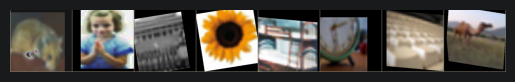

hamster girl  castle sunflower bed   clock keyboard camel


In [4]:
show_sample_batch(trainloader, CIFAR100_CLASSES)

## Model Definition

### Bottleneck Block
The standard ResNet bottleneck block: 1×1 conv (reduce) → 3×3 conv →
1×1 conv (expand, ×4) with BatchNorm and a shortcut connection
(identity or 1×1 projection). The `expansion = 4` factor means the
output channels are 4× the intermediate ("planes") width.

### ResNet50
4 stages with [3, 4, 6, 3] `Bottleneck` blocks — totaling ~23.5M parameters.
Uses a CIFAR-friendly 3×3 stem (no 7×7 conv or initial max-pooling).

In [5]:
class Bottleneck(nn.Module):
    """ResNet Bottleneck block: 1×1 → 3×3 → 1×1 with expansion=4."""
    expansion = 4

    def __init__(self, in_planes, planes, stride=1):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, self.expansion * planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion * planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet50(nn.Module):
    def __init__(self, num_classes=100):
        super(ResNet50, self).__init__()
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(Bottleneck(self.in_planes, planes, s))
            self.in_planes = planes * Bottleneck.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.maxpool(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

## Initialize Model & Print Summary

In [6]:
model = ResNet50(100).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

ResNet50(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momen

## Training Configuration

In [7]:
criterion = nn.CrossEntropyLoss()
epochs = 90
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.10,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=1e4,
)

# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

scaler = torch.amp.GradScaler('cuda')
NAME = 'resnet50_100'
checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path=f'../../checkpoint/{NAME}_latest.pth',
    best_model_path=f'../../checkpoint/{NAME}_best.pth',
    mode='max',
    verbose=True,
)

## Training Loop

In [8]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
    step_scheduler_per_batch=True,
    log=True
)

[RunLogger] Logging to 'C:\Users\asmit\PycharmProjects\CIFAR_10\logs\ipykernel_launcher/'  —  run: 'resnet50_20260607_145707'
[ModelCheckpoint] New best (max): 7.1700 — saved to ..\checkpoint\resnet50_100_best.pth
Epoch [ 1/90]  Train Loss: 4.5046  Val Loss: 3.9988  Val Acc: 7.17%  LR: 0.012716  Time: 58.88s
[ModelCheckpoint] New best (max): 10.1900 — saved to ..\checkpoint\resnet50_100_best.pth
Epoch [ 2/90]  Train Loss: 4.0684  Val Loss: 3.7810  Val Acc: 10.19%  LR: 0.020535  Time: 44.55s
[ModelCheckpoint] New best (max): 13.1900 — saved to ..\checkpoint\resnet50_100_best.pth
Epoch [ 3/90]  Train Loss: 3.8799  Val Loss: 3.6270  Val Acc: 13.19%  LR: 0.032514  Time: 44.42s
[ModelCheckpoint] New best (max): 19.0600 — saved to ..\checkpoint\resnet50_100_best.pth
Epoch [ 4/90]  Train Loss: 3.6290  Val Loss: 3.3364  Val Acc: 19.06%  LR: 0.047208  Time: 44.95s
[ModelCheckpoint] New best (max): 24.3700 — saved to ..\checkpoint\resnet50_100_best.pth
Epoch [ 5/90]  Train Loss: 3.3153  Val Loss

## Restore Best Weights & Test Evaluation

In [9]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:5s}: {acc:.1f}%')

[ModelCheckpoint] Restored best weights from ..\checkpoint\resnet50_100_best.pth (score=79.2600)

Overall Test Accuracy: 79.19%

  apple: 91.0%
  aquarium_fish: 92.0%
  baby : 74.0%
  bear : 71.0%
  beaver: 72.0%
  bed  : 85.0%
  bee  : 82.0%
  beetle: 83.0%
  bicycle: 92.0%
  bottle: 88.0%
  bowl : 60.0%
  boy  : 47.0%
  bridge: 86.0%
  bus  : 72.0%
  butterfly: 80.0%
  camel: 88.0%
  can  : 76.0%
  castle: 87.0%
  caterpillar: 78.0%
  cattle: 68.0%
  chair: 90.0%
  chimpanzee: 93.0%
  clock: 82.0%
  cloud: 86.0%
  cockroach: 89.0%
  couch: 67.0%
  crab : 73.0%
  crocodile: 74.0%
  cup  : 83.0%
  dinosaur: 78.0%
  dolphin: 73.0%
  elephant: 81.0%
  flatfish: 73.0%
  forest: 72.0%
  fox  : 86.0%
  girl : 57.0%
  hamster: 85.0%
  house: 86.0%
  kangaroo: 79.0%
  keyboard: 94.0%
  lamp : 81.0%
  lawn_mower: 90.0%
  leopard: 77.0%
  lion : 85.0%
  lizard: 65.0%
  lobster: 69.0%
  man  : 55.0%
  maple_tree: 68.0%
  motorcycle: 89.0%
  mountain: 91.0%
  mouse: 64.0%
  mushroom: 76.0%
  oak_

## Training Curves

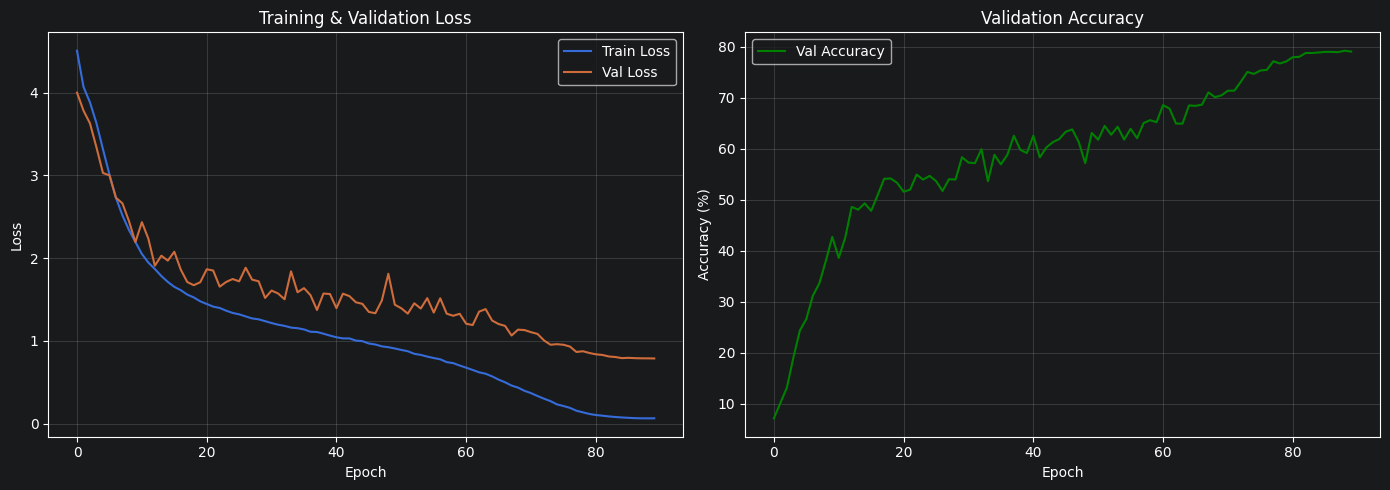

In [10]:
plot_training_curves(train_losses, val_losses, val_accuracies)